# Scratch versus ImageNet-pretrained ResNet-18

This notebook compares the two completed experiments using their saved result bundles. It does not load the image dataset or model checkpoints, so it can be run quickly from a fresh repository checkout.

In [ ]:
from pathlib import Path
import sys

candidates = (Path.cwd(), *Path.cwd().parents)
REPO_ROOT = next(
    (path.resolve() for path in candidates if (path / "pyproject.toml").is_file() and (path / "results").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Open this notebook from a local project checkout.")

sys.path.insert(0, str(REPO_ROOT / "src"))
from inat_project.paths import get_project_paths

PATHS = get_project_paths(REPO_ROOT)
RESULT_ROOT = PATHS.results_root
COMPARISON_ROOT = RESULT_ROOT / "comparison"
FIGURE_ROOT = COMPARISON_ROOT / "figures"
COMPARISON_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Repository: {REPO_ROOT}")

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
EXPERIMENTS = ("scratch", "pretrained")
COLORS = {"scratch": "#4C78A8", "pretrained": "#F58518"}

In [3]:
metrics = {}
runtime = {}
history = {}
predictions = {}
confusions = {}

for experiment in EXPERIMENTS:
    experiment_root = RESULT_ROOT / experiment
    required = [
        experiment_root / "metrics.json",
        experiment_root / "runtime.json",
        experiment_root / "training_history.csv",
        experiment_root / "test_predictions.csv",
        experiment_root / "confused_pairs.csv",
    ]
    missing = [path for path in required if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Missing {experiment} results: {missing}")

    with required[0].open(encoding="utf-8") as handle:
        metrics[experiment] = json.load(handle)
    with required[1].open(encoding="utf-8") as handle:
        runtime[experiment] = json.load(handle)
    history[experiment] = pd.read_csv(required[2])
    predictions[experiment] = pd.read_csv(required[3])
    confusions[experiment] = pd.read_csv(required[4])

scratch_test = predictions["scratch"]
pretrained_test = predictions["pretrained"]
if not scratch_test["path"].equals(pretrained_test["path"]):
    raise ValueError("Prediction files do not contain the same test images in the same order.")
if not scratch_test["true_idx"].equals(pretrained_test["true_idx"]):
    raise ValueError("Prediction files do not use the same ground-truth labels.")

print(f"Verified a paired comparison on {len(scratch_test):,} identical test images.")

Verified a paired comparison on 5,000 identical test images.


## Test-set performance

In [4]:
metric_labels = {
    "top1_accuracy": "Top-1 accuracy",
    "top5_accuracy": "Top-5 accuracy",
    "balanced_accuracy": "Balanced accuracy",
    "macro_precision": "Macro precision",
    "macro_recall": "Macro recall",
    "macro_f1": "Macro F1",
}
performance_rows = []
for key, label in metric_labels.items():
    scratch_value = 100 * metrics["scratch"][key]
    pretrained_value = 100 * metrics["pretrained"][key]
    performance_rows.append(
        {
            "metric": label,
            "scratch_percent": scratch_value,
            "pretrained_percent": pretrained_value,
            "improvement_points": pretrained_value - scratch_value,
            "relative_improvement_percent": 100 * (pretrained_value / scratch_value - 1),
        }
    )

performance = pd.DataFrame(performance_rows).set_index("metric")
performance.to_csv(COMPARISON_ROOT / "metric_comparison.csv")
display(performance.round(2))

,scratch_percent,pretrained_percent,improvement_points,relative_improvement_percent
metric,,,,
Top-1 accuracy,41.98,66.02,24.04,57.27
Top-5 accuracy,63.46,83.30,19.84,31.26
Balanced accuracy,41.98,66.02,24.04,57.27
Macro precision,42.42,67.75,25.33,59.70
Macro recall,41.98,66.02,24.04,57.27
Macro F1,41.28,65.76,24.48,59.29


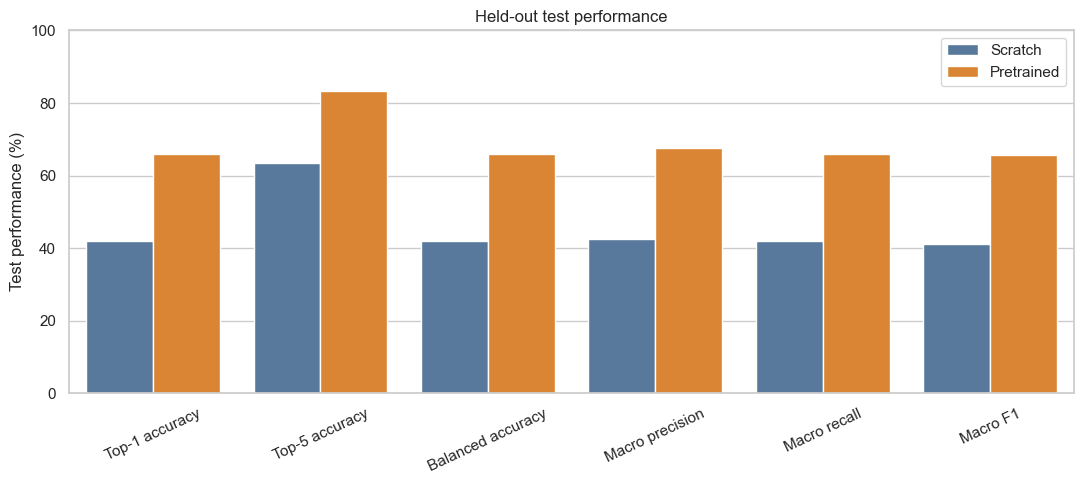

In [5]:
plot_frame = (
    performance[["scratch_percent", "pretrained_percent"]]
    .rename(columns={"scratch_percent": "Scratch", "pretrained_percent": "Pretrained"})
    .reset_index()
    .melt(id_vars="metric", var_name="model", value_name="percent")
)
figure, axis = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=plot_frame,
    x="metric",
    y="percent",
    hue="model",
    palette=[COLORS["scratch"], COLORS["pretrained"]],
    ax=axis,
)
axis.set(xlabel="", ylabel="Test performance (%)", title="Held-out test performance", ylim=(0, 100))
axis.tick_params(axis="x", rotation=25)
axis.legend(title="")
figure.tight_layout()
figure.savefig(FIGURE_ROOT / "metric_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## Training and inference efficiency

`training_seconds` is the cumulative time required to reach the selected best checkpoint. Total executed time also includes epochs run after that checkpoint.

,best_epoch,hours_to_best_checkpoint,total_executed_hours,test_inference_seconds,images_per_second,device
model,,,,,,
scratch,53,3.76,4.24,22.84,218.96,mps
pretrained,22,1.56,2.13,22.99,217.49,mps


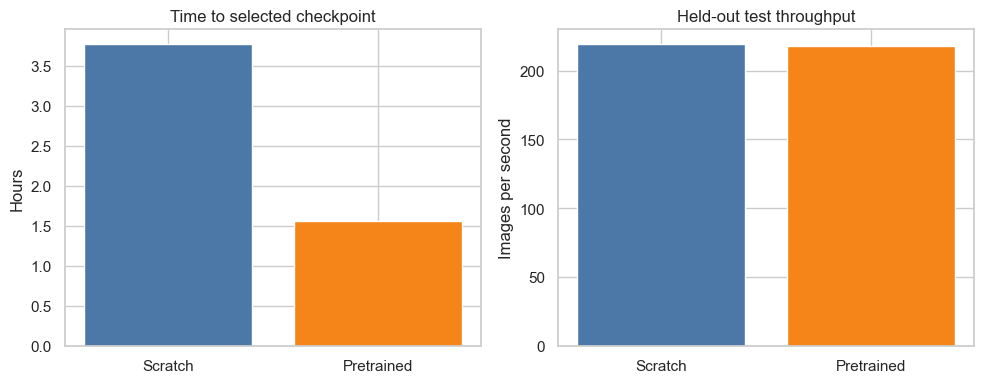

In [6]:
efficiency_rows = []
for experiment in EXPERIMENTS:
    total_executed_seconds = history[experiment]["epoch_seconds"].sum()
    efficiency_rows.append(
        {
            "model": experiment,
            "best_epoch": int(metrics[experiment]["best_epoch"]),
            "hours_to_best_checkpoint": metrics[experiment]["training_seconds"] / 3600,
            "total_executed_hours": total_executed_seconds / 3600,
            "test_inference_seconds": metrics[experiment]["inference_seconds"],
            "images_per_second": metrics[experiment]["images_per_second"],
            "device": runtime[experiment]["device_name"],
        }
    )
efficiency = pd.DataFrame(efficiency_rows).set_index("model")
efficiency.to_csv(COMPARISON_ROOT / "efficiency_comparison.csv")
display(efficiency.round(2))

figure, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(
    ["Scratch", "Pretrained"],
    efficiency["hours_to_best_checkpoint"],
    color=[COLORS["scratch"], COLORS["pretrained"]],
)
axes[0].set(ylabel="Hours", title="Time to selected checkpoint")
axes[1].bar(
    ["Scratch", "Pretrained"],
    efficiency["images_per_second"],
    color=[COLORS["scratch"], COLORS["pretrained"]],
)
axes[1].set(ylabel="Images per second", title="Held-out test throughput")
figure.tight_layout()
figure.savefig(FIGURE_ROOT / "efficiency_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## Learning behaviour and generalisation

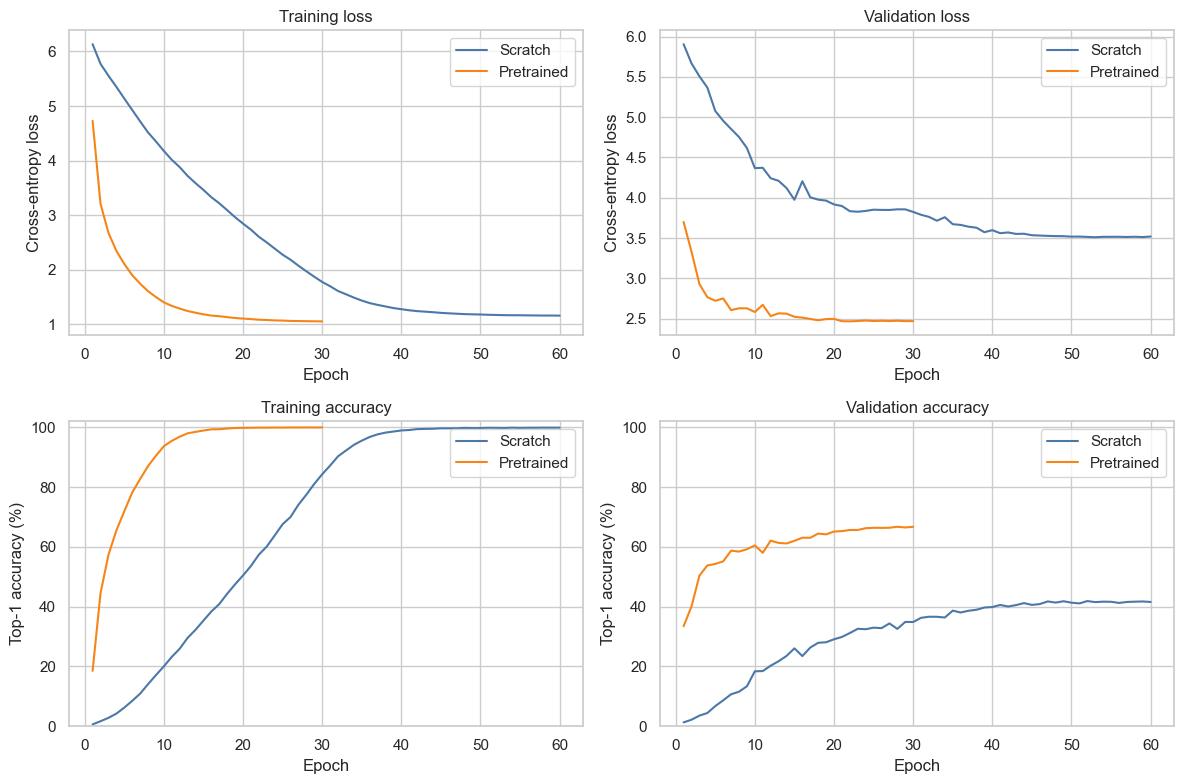

In [7]:
figure, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)
for experiment in EXPERIMENTS:
    frame = history[experiment]
    label = experiment.title()
    color = COLORS[experiment]
    axes[0, 0].plot(frame["epoch"], frame["train_loss"], label=label, color=color)
    axes[0, 1].plot(frame["epoch"], frame["validation_loss"], label=label, color=color)
    axes[1, 0].plot(frame["epoch"], 100 * frame["train_top1"], label=label, color=color)
    axes[1, 1].plot(frame["epoch"], 100 * frame["validation_top1"], label=label, color=color)

axes[0, 0].set(title="Training loss", xlabel="Epoch", ylabel="Cross-entropy loss")
axes[0, 1].set(title="Validation loss", xlabel="Epoch", ylabel="Cross-entropy loss")
axes[1, 0].set(title="Training accuracy", xlabel="Epoch", ylabel="Top-1 accuracy (%)", ylim=(0, 102))
axes[1, 1].set(title="Validation accuracy", xlabel="Epoch", ylabel="Top-1 accuracy (%)", ylim=(0, 102))
for axis in axes.flat:
    axis.legend()
figure.tight_layout()
figure.savefig(FIGURE_ROOT / "learning_curves_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

,training_percent,validation_percent,test_percent,train_test_gap_points
model,,,,
scratch,99.8,41.54,41.98,57.82
pretrained,99.9,65.66,66.02,33.89


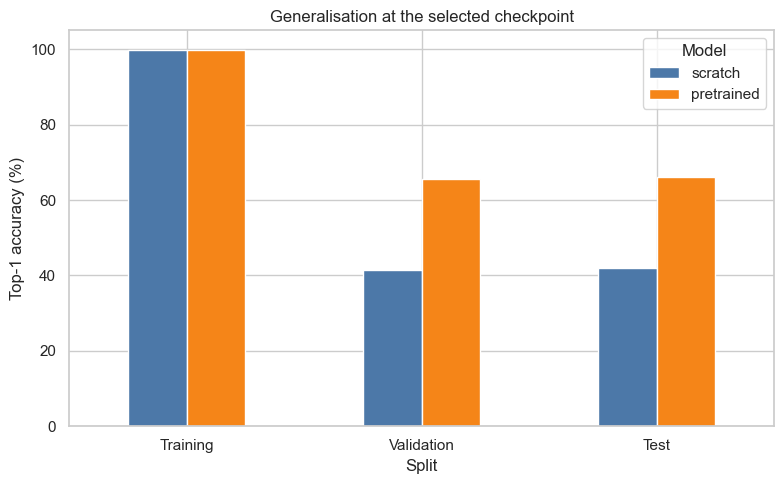

In [8]:
generalisation_rows = []
for experiment in EXPERIMENTS:
    best_epoch = int(metrics[experiment]["best_epoch"])
    best_row = history[experiment].loc[history[experiment]["epoch"].eq(best_epoch)].iloc[0]
    train_accuracy = 100 * best_row["train_top1"]
    validation_accuracy = 100 * best_row["validation_top1"]
    test_accuracy = 100 * metrics[experiment]["top1_accuracy"]
    generalisation_rows.append(
        {
            "model": experiment,
            "training_percent": train_accuracy,
            "validation_percent": validation_accuracy,
            "test_percent": test_accuracy,
            "train_test_gap_points": train_accuracy - test_accuracy,
        }
    )
generalisation = pd.DataFrame(generalisation_rows).set_index("model")
display(generalisation.round(2))

generalisation_plot = (
    generalisation[["training_percent", "validation_percent", "test_percent"]]
    .rename(
        columns={
            "training_percent": "Training",
            "validation_percent": "Validation",
            "test_percent": "Test",
        }
    )
    .T
)
axis = generalisation_plot.plot(
    kind="bar",
    figsize=(8, 5),
    color=[COLORS["scratch"], COLORS["pretrained"]],
)
axis.set(xlabel="Split", ylabel="Top-1 accuracy (%)", title="Generalisation at the selected checkpoint", ylim=(0, 105))
axis.tick_params(axis="x", rotation=0)
axis.legend(title="Model")
axis.figure.tight_layout()
axis.figure.savefig(FIGURE_ROOT / "generalisation_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## Paired test-image analysis

Because both models were evaluated on the same images, the difference can be analysed per image rather than as two unrelated accuracy estimates.

In [9]:
def boolean_values(series):
    if series.dtype == bool:
        return series.to_numpy()
    return series.astype(str).str.lower().eq("true").to_numpy()

scratch_correct = boolean_values(scratch_test["correct"])
pretrained_correct = boolean_values(pretrained_test["correct"])
paired_difference = pretrained_correct.astype(int) - scratch_correct.astype(int)
difference_points = 100 * paired_difference.mean()
standard_error_points = 100 * paired_difference.std(ddof=1) / np.sqrt(len(paired_difference))
ci_low = difference_points - 1.96 * standard_error_points
ci_high = difference_points + 1.96 * standard_error_points

agreement = pd.Series(
    {
        "both_correct": int((scratch_correct & pretrained_correct).sum()),
        "pretrained_only_correct": int((~scratch_correct & pretrained_correct).sum()),
        "scratch_only_correct": int((scratch_correct & ~pretrained_correct).sum()),
        "both_incorrect": int((~scratch_correct & ~pretrained_correct).sum()),
    },
    name="test_images",
).to_frame()
display(agreement)
display(
    Markdown(
        f"**Paired top-1 improvement:** {difference_points:.2f} percentage points "
        f"(approximate 95% CI: {ci_low:.2f} to {ci_high:.2f})."
    )
)

,test_images
both_correct,1887
pretrained_only_correct,1414
scratch_only_correct,212
both_incorrect,1487


**Paired top-1 improvement:** 24.04 percentage points (approximate 95% CI: 22.61 to 25.47).

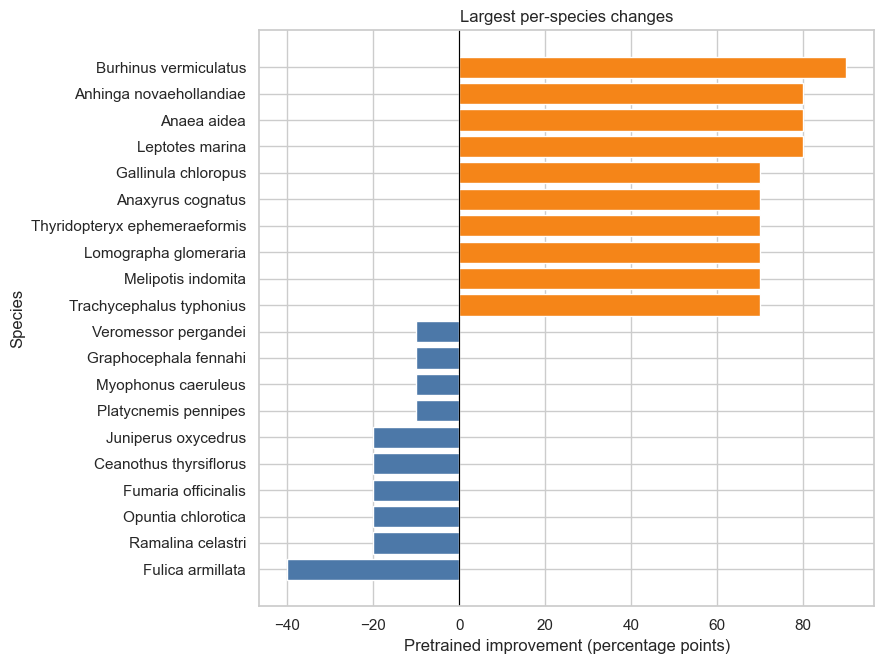

In [10]:
def species_name(class_name):
    parts = str(class_name).split("_")
    return " ".join(parts[-2:])

per_class = None
for experiment in EXPERIMENTS:
    frame = predictions[experiment].copy()
    frame["correct_value"] = boolean_values(frame["correct"]).astype(float)
    grouped = frame.groupby("true_class")["correct_value"].agg(["mean", "size"])
    grouped = grouped.rename(
        columns={"mean": f"{experiment}_accuracy", "size": f"{experiment}_images"}
    )
    per_class = grouped if per_class is None else per_class.join(grouped, how="inner")

per_class["scratch_percent"] = 100 * per_class["scratch_accuracy"]
per_class["pretrained_percent"] = 100 * per_class["pretrained_accuracy"]
per_class["improvement_points"] = per_class["pretrained_percent"] - per_class["scratch_percent"]
per_class["species"] = [species_name(name) for name in per_class.index]
per_class.to_csv(COMPARISON_ROOT / "per_class_comparison.csv")

largest_gains = per_class.nlargest(10, "improvement_points")
largest_losses = per_class.nsmallest(10, "improvement_points")
shown = pd.concat([largest_losses, largest_gains]).drop_duplicates().sort_values("improvement_points")
figure, axis = plt.subplots(figsize=(9, max(6, 0.34 * len(shown))))
colors = [COLORS["pretrained"] if value >= 0 else COLORS["scratch"] for value in shown["improvement_points"]]
axis.barh(shown["species"], shown["improvement_points"], color=colors)
axis.axvline(0, color="black", linewidth=0.8)
axis.set(xlabel="Pretrained improvement (percentage points)", ylabel="Species", title="Largest per-species changes")
figure.tight_layout()
figure.savefig(FIGURE_ROOT / "per_class_changes.png", dpi=200, bbox_inches="tight")
plt.show()

## Most frequent confusions

In [11]:
for experiment in EXPERIMENTS:
    shown = confusions[experiment].head(10).copy()
    shown["true_species"] = shown["true_class"].map(species_name)
    shown["predicted_species"] = shown["predicted_class"].map(species_name)
    display(Markdown(f"### {experiment.title()} model"))
    display(shown[["true_species", "predicted_species", "count"]].reset_index(drop=True))

### Scratch model

,true_species,predicted_species,count
0,Lupinus perennis,Agastache foeniculum,5
1,Enallagma durum,Platycnemis pennipes,5
2,Plethodon cinereus,Plethodon dorsalis,4
3,Polites sabuleti,Atalopedes campestris,4
4,Amphicarpaea bracteata,Fraxinus nigra,4
5,Platycnemis pennipes,Enallagma durum,3
6,Sialia sialis,Sialia mexicana,3
7,Pleurozium schreberi,Plagiothecium undulatum,3
8,Coereba flaveola,Leptocoma zeylonica,3
9,Orthetrum sabina,Diplacodes trivialis,3


### Pretrained model

,true_species,predicted_species,count
0,Perca fluviatilis,Morone americana,4
1,Tringa semipalmata,Numenius phaeopus,4
2,Charadrius semipalmatus,Charadrius wilsonia,4
3,Polites sabuleti,Atalopedes campestris,4
4,Empidonax flaviventris,Empidonax occidentalis,3
5,Latrodectus mactans,Steatoda capensis,3
6,Prosthemadera novaeseelandiae,Melanotis caerulescens,3
7,Houttuynia cordata,Viola mirabilis,3
8,Dactylorhiza viridis,Platanthera clavellata,3
9,Leucorrhinia hudsonica,Cordulegaster maculata,3


## Report-ready conclusion

In [12]:
scratch_top1 = 100 * metrics["scratch"]["top1_accuracy"]
pretrained_top1 = 100 * metrics["pretrained"]["top1_accuracy"]
scratch_top5 = 100 * metrics["scratch"]["top5_accuracy"]
pretrained_top5 = 100 * metrics["pretrained"]["top5_accuracy"]
scratch_f1 = 100 * metrics["scratch"]["macro_f1"]
pretrained_f1 = 100 * metrics["pretrained"]["macro_f1"]
time_speedup = metrics["scratch"]["training_seconds"] / metrics["pretrained"]["training_seconds"]

display(
    Markdown(
        f"The ImageNet-pretrained ResNet-18 achieved **{pretrained_top1:.2f}% top-1** and "
        f"**{pretrained_top5:.2f}% top-5** accuracy on the held-out 5,000-image test set, "
        f"compared with **{scratch_top1:.2f}% top-1** and **{scratch_top5:.2f}% top-5** "
        f"for the randomly initialised model. Pretraining therefore improved top-1 accuracy by "
        f"**{pretrained_top1 - scratch_top1:.2f} percentage points**. Macro F1 increased from "
        f"**{scratch_f1:.2f}%** to **{pretrained_f1:.2f}%**, showing that the gain was distributed "
        f"across the balanced class set rather than being driven by a small subset of species. "
        f"The selected pretrained checkpoint was reached **{time_speedup:.2f}× faster** than the "
        f"selected scratch checkpoint on the same MPS device. Both models eventually fitted the "
        f"training data almost perfectly, but the pretrained model retained substantially better "
        f"validation and test performance. These results support the conclusion that ImageNet "
        f"initialisation provides more transferable visual features and better sample efficiency "
        f"for this 500-species classification task."
    )
)

The ImageNet-pretrained ResNet-18 achieved **66.02% top-1** and **83.30% top-5** accuracy on the held-out 5,000-image test set, compared with **41.98% top-1** and **63.46% top-5** for the randomly initialised model. Pretraining therefore improved top-1 accuracy by **24.04 percentage points**. Macro F1 increased from **41.28%** to **65.76%**, showing that the gain was distributed across the balanced class set rather than being driven by a small subset of species. The selected pretrained checkpoint was reached **2.41× faster** than the selected scratch checkpoint on the same MPS device. Both models eventually fitted the training data almost perfectly, but the pretrained model retained substantially better validation and test performance. These results support the conclusion that ImageNet initialisation provides more transferable visual features and better sample efficiency for this 500-species classification task.